In [32]:
import mlflow
import pandas as pd
import mlflow.sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , precision_score , recall_score,f1_score,classification_report, confusion_matrix
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns


In [33]:
mlflow.set_tracking_uri("https://dagshub.com/Aayush10671/yt-comment-sentiment-analysis.mlflow")


In [35]:
import dagshub
dagshub.init(repo_owner='Aayush10671', repo_name='yt-comment-sentiment-analysis', mlflow=True)

import mlflow
with mlflow.start_run():
  mlflow.log_param('parameter name', 'value')
  mlflow.log_metric('metric name', 1)

Initialized MLflow to track repo "Aayush10671/yt-comment-sentiment-analysis"

Repository Aayush10671/yt-comment-sentiment-analysis initialized!

RestException: INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}

In [36]:
mlflow.set_experiment("exp-2 BoW and tfidf..")

2026/07/25 20:02:45 INFO mlflow.tracking.fluent: Experiment with name 'exp-2 BoW and tfidf..' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/644838f341d24b579488fce339fe2574', creation_time=1784989965527, experiment_id='3', last_update_time=1784989965527, lifecycle_stage='active', name='exp-2 BoW and tfidf..', tags={}, workspace='default'>

In [37]:
df = pd.read_csv("preprocessed_data.csv")
df.shape

(36793, 2)

In [38]:
print(df['clean_comment'].isnull().sum())          # count of NaN
print(df['clean_comment'].dtype)                   # should be object or string
print(df['clean_comment'].apply(type).value_counts())  # see if all are strings
print(df['clean_comment'].str.len().value_counts().head()) # check empty strings

131
object
clean_comment
<class 'str'>      36662
<class 'float'>      131
Name: count, dtype: int64
clean_comment
14.0    439
15.0    429
24.0    421
19.0    420
22.0    416
Name: count, dtype: int64


In [39]:
df = df.dropna(subset=['clean_comment'])

In [40]:
df['clean_comment'] = df['clean_comment'].astype(str)

In [41]:
df = df[df['clean_comment'].str.strip() != '']

In [42]:
# Drop rows where clean_comment is missing
df = df.dropna(subset=['clean_comment'])
# Remove rows where the comment is empty after stripping
df = df[df['clean_comment'].str.strip() != '']
# Ensure all values are strings (just in case)
df['clean_comment'] = df['clean_comment'].astype(str)

In [45]:
df = df.dropna(subset=['clean_comment'])
df = df[df['clean_comment'].str.strip() != '']
df['clean_comment'] = df['clean_comment'].astype(str)

In [49]:
def run_experiment(vectorizer_type , ngram_range , vectirizer_max_feature , vectorizer_name):

    if vectorizer_type == "BoW":
        vectorizer = CountVectorizer(max_features=vectirizer_max_feature , ngram_range=ngram_range)
    else:
        vectorizer = TfidfVectorizer(max_features=vectirizer_max_feature , ngram_range=ngram_range)

    X = vectorizer.fit_transform(df['clean_comment']).toarray()
    y = df['category'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    with mlflow.start_run():

        mlflow.set_tag("vectorizer", vectorizer_name)
        mlflow.set_tag("model_type", "RandomForestClassifier")

        mlflow.log_param("vectorizer_type", vectorizer_type)
        mlflow.log_param("ngram_range", ngram_range)
        mlflow.log_param("vectirizer_max_feature", vectirizer_max_feature)

        n_estimators = 200
        max_depth = 15

        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("max_depth", max_depth)

        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        mlflow.log_metric("accuracy", accuracy)

        classification_rep = classification_report(y_test, y_pred, output_dict=True)

        for label, metrics in classification_rep.items():
            if label not in ['accuracy', 'macro avg', 'weighted avg']:
                for metric_name, metric_value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric_name}", metric_value)


        confusion_mat = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(8, 6))
        sns.heatmap(confusion_mat , annot = True)
        plt.xlabel("preficted")
        plt.ylabel("actual")
        plt.title("confusion_matrix", fontdict=None, loc='center') 
        plt.savefig("confusion_matrix.png")

        mlflow.sklearn.log_model(model , f"random forest model {vectorizer_name} - {ngram_range}")

        mlflow.log_artifact("confusion_matrix.png")


2026/07/25 20:12:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/25 20:12:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run fearless-steed-589 at: https://dagshub.com/Aayush10671/yt-comment-sentiment-analysis.mlflow/#/experiments/3/runs/70c0c0aa4bfb47a2a877216404285dae
🧪 View experiment at: https://dagshub.com/Aayush10671/yt-comment-sentiment-analysis.mlflow/#/experiments/3


2026/07/25 20:13:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/25 20:13:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run aged-fowl-12 at: https://dagshub.com/Aayush10671/yt-comment-sentiment-analysis.mlflow/#/experiments/3/runs/688d1c2a77114cdc8a8b1a42b17c1e33
🧪 View experiment at: https://dagshub.com/Aayush10671/yt-comment-sentiment-analysis.mlflow/#/experiments/3


2026/07/25 20:15:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/25 20:15:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

🏃 View run respected-toad-387 at: https://dagshub.com/Aayush10671/yt-comment-sentiment-analysis.mlflow/#/experiments/3/runs/72ca25e5e661426897a6262d60275937
🧪 View experiment at: https://dagshub.com/Aayush10671/yt-comment-sentiment-analysis.mlflow/#/experiments/3


2026/07/25 20:19:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/25 20:19:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run respected-gnat-356 at: https://dagshub.com/Aayush10671/yt-comment-sentiment-analysis.mlflow/#/experiments/3/runs/9c6d712e4acb4f438e5ba14173f56443
🧪 View experiment at: https://dagshub.com/Aayush10671/yt-comment-sentiment-analysis.mlflow/#/experiments/3


2026/07/25 20:20:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/25 20:20:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run wise-croc-797 at: https://dagshub.com/Aayush10671/yt-comment-sentiment-analysis.mlflow/#/experiments/3/runs/e6cfefdeb5b14c07b1d6af6d43e3ca8e
🧪 View experiment at: https://dagshub.com/Aayush10671/yt-comment-sentiment-analysis.mlflow/#/experiments/3


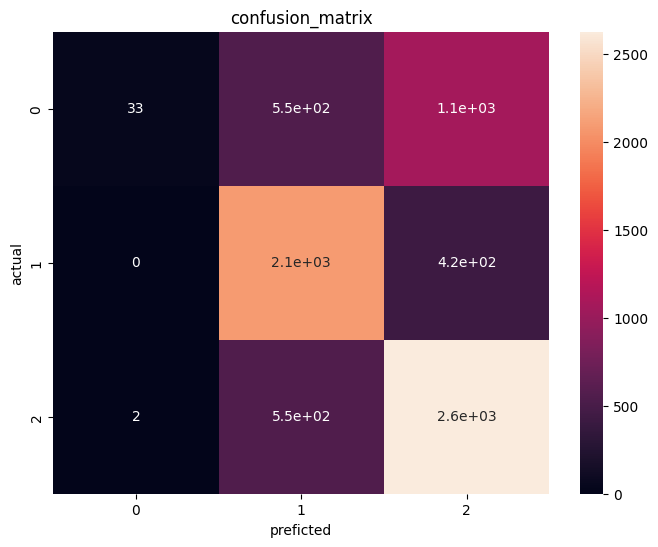

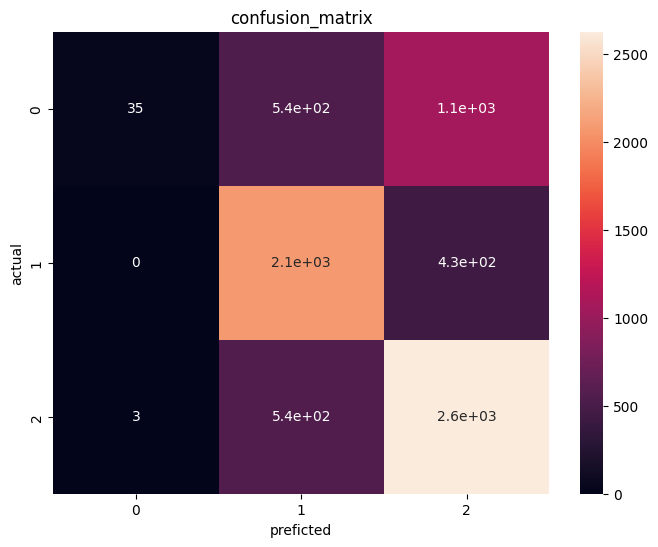

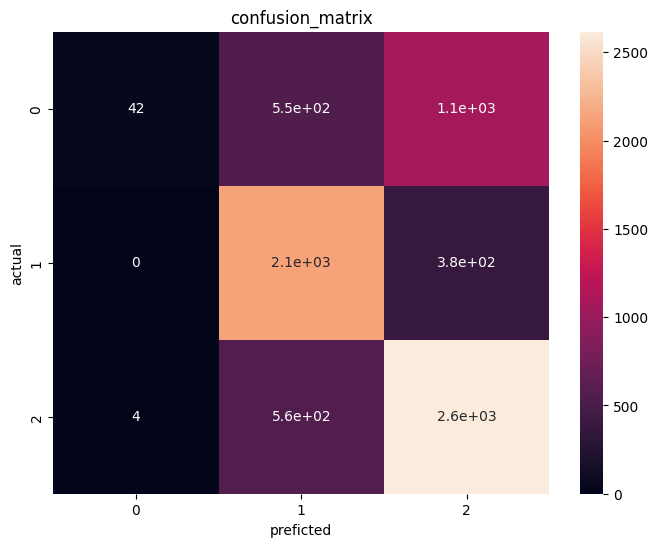

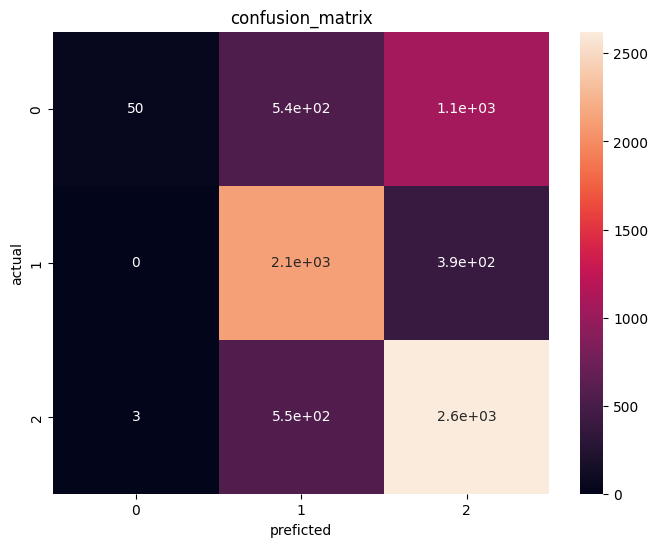

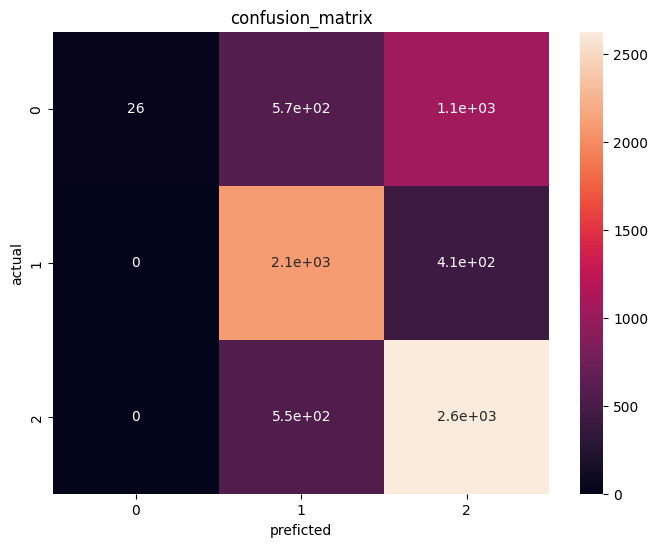

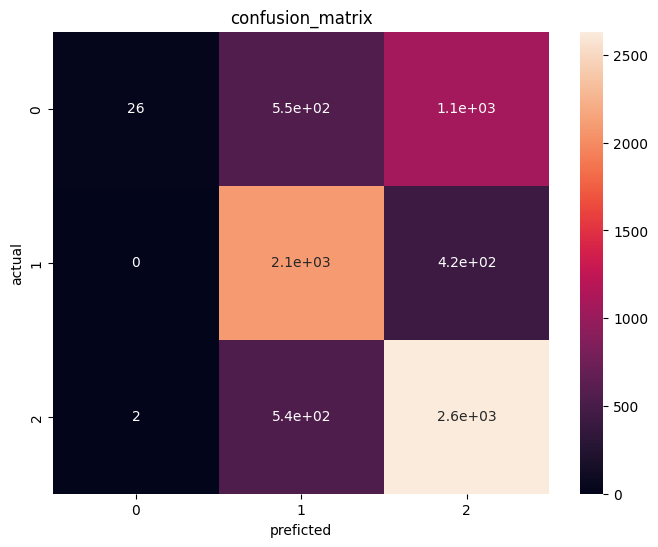

In [50]:
ngram_ranges = [(1,1) , (1,2) , (1,3)]

max_features = 5000


for ngram_range in ngram_ranges:
    run_experiment("BoW" , ngram_range , max_features , vectorizer_name = "BoW")
    run_experiment("tf-idf" , ngram_range , max_features , vectorizer_name = "tf-idf")

In [46]:
df.head(5)

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1
